# 🚀 ENGIN Hackathon: Kompletny Pipeline i Porównanie Modeli

Ten notebook jest **samowystarczalny**. Zawiera:
1. **Ładowanie danych**: Automatyczne wykrywanie kolumn i obsługa braków.
2. **Feature Engineering**: 188+ cech (widmo, statystyki, pasma, cechy względem silnika).
3. **Porównanie Modeli**: XGBoost vs LightGBM vs ExtraTrees vs RandomForest.
4. **Walidacja**: GroupKFold (grupowanie po silnikach) - kluczowe dla uczciwej oceny.
5. **Detekcja Unknown**: Optymalizacja progów pewności.
6. **Severity**: Osobne modele dla poważności usterek.
7. **Wizualizacja**: Wykresy wyników i przykładowe predykcje.

## 1. Konfiguracja i Importy

In [47]:
!pip install pandas numpy scikit-learn xgboost lightgbm matplotlib seaborn plotly tqdm joblib scipy -q

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
import xgboost as xgb
import lightgbm as lgb
import joblib
import warnings
from tqdm import tqdm

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# --- KONFIGURACJA HIPERPARAMETRÓW ---
CONFIG = {
    'data_dir': 'data',  # Zmień na ścieżkę do swoich danych
    'random_state': 42,
    'n_folds': 5,
    'features': {
        'use_engine_relative': True,  # Cechy względem innych cylindrów silnika
        'use_spectrum': True,
        'use_stats': True,
        'use_bands': True
    },
    'models': {
        'xgboost': {
            'n_estimators': 300,
            'max_depth': 6,
            'learning_rate': 0.05,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'tree_method': 'hist'
        },
        'lightgbm': {
            'n_estimators': 300,
            'max_depth': 6,
            'learning_rate': 0.05,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'verbose': -1
        },
        'extratrees': {
            'n_estimators': 300,
            'max_depth': None,
            'class_weight': 'balanced',
            'n_jobs': -1
        },
        'randomforest': {
            'n_estimators': 300,
            'max_depth': None,
            'class_weight': 'balanced',
            'n_jobs': -1
        }
    },
    'unknown_threshold': 0.35,  # Poniżej tej pewności -> unknown
    'severity_models': True
}

print("✅ Konfiguracja załadowana")

✅ Konfiguracja załadowana


## 2. Ładowanie i Przygotowanie Danych

In [49]:
def load_data(data_dir):
    """Ładuje dane z automatycznym wykrywaniem kolumn."""
    try:
        train = pd.read_csv(f"{data_dir}/train.csv")
        val = pd.read_csv(f"{data_dir}/val.csv")
        test = pd.read_csv(f"{data_dir}/test.csv")
    except FileNotFoundError:
        print(f"❌ Błąd: Nie znaleziono plików w {data_dir}. Upewnij się, że pliki train.csv, val.csv, test.csv tam są.")
        return None, None, None

    # Normalizacja nazw kolumn (małe litery)
    for df in [train, val, test]:
        df.columns = df.columns.str.lower().str.strip()
    
    # Wykrywanie kolumn silnika i cylindra
    engine_col = 'engine' if 'engine' in train.columns else 'engine_id' if 'engine_id' in train.columns else train.columns[0]
    cyl_col = 'cylinder' if 'cylinder' in train.columns else 'cyl' if 'cyl' in train.columns else train.columns[1]
    
    # Wykrywanie kolumn widma (bez identyfikatorów i targetów)
    excluded_cols = [engine_col, cyl_col, 'n_cylinders', 'label', 'severity']
    spectrum_cols = [c for c in train.columns if c not in excluded_cols and not train[c].dtype == 'object']
    
    print(f"📊 Kolumny wykryte:")
    print(f"   Silnik: '{engine_col}'")
    print(f"   Cylinder: '{cyl_col}'")
    print(f"   Widmo: {len(spectrum_cols)} kolumn (od {spectrum_cols[0]} do {spectrum_cols[-1]})")
    print(f"   Train: {len(train)} wierszy, Val: {len(val)} wierszy, Test: {len(test)} wierszy")
    
    return train, val, test, engine_col, cyl_col, spectrum_cols

train_df, val_df, test_df, engine_col, cyl_col, spectrum_cols = load_data(CONFIG['data_dir'])

if train_df is None:
    raise StopIteration("Zatrzymywanie wykonania z powodu braku danych.")

📊 Kolumny wykryte:
   Silnik: 'engine_id'
   Cylinder: 'cylinder'
   Widmo: 21 kolumn (od mv_0 do mv_20)
   Train: 2400 wierszy, Val: 476 wierszy, Test: 600 wierszy


## 3. Feature Engineering (188+ Cech)

In [50]:
def extract_features(df, engine_col, cyl_col, spectrum_cols, config):
    """Generuje cechy: surowe, statystyki, pasma, cechy względem silnika."""
    df = df.copy()
    
    # 1. Interpolacja brakujących danych w widmie
    df[spectrum_cols] = df[spectrum_cols].interpolate(method='linear', axis=1)
    df[spectrum_cols] = df[spectrum_cols].fillna(0)
    
    features = pd.DataFrame(index=df.index)
    features[engine_col] = df[engine_col]
    features[cyl_col] = df[cyl_col]
    
    # A. Surowe widmo (21 cech)
    if config['features']['use_spectrum']:
        for col in spectrum_cols:
            features[f'raw_{col}'] = df[col]
    
    # B. Statystyki widma
    if config['features']['use_stats']:
        spectrum_vals = df[spectrum_cols].values
        features['stat_mean'] = np.mean(spectrum_vals, axis=1)
        features['stat_std'] = np.std(spectrum_vals, axis=1)
        features['stat_min'] = np.min(spectrum_vals, axis=1)
        features['stat_max'] = np.max(spectrum_vals, axis=1)
        features['stat_median'] = np.median(spectrum_vals, axis=1)
        features['stat_range'] = features['stat_max'] - features['stat_min']
        features['stat_rms'] = np.sqrt(np.mean(spectrum_vals**2, axis=1))
        spectrum_frame = pd.DataFrame(spectrum_vals, index=df.index)
        features['stat_skew'] = spectrum_frame.skew(axis=1).values
        features['stat_kurt'] = spectrum_frame.kurtosis(axis=1).values
    
    # C. Energia w pasmach (0-20kHz podzielone na 7 pasm)
    if config['features']['use_bands']:
        n_bands = 7
        band_size = len(spectrum_cols) // n_bands
        for i in range(n_bands):
            start = i * band_size
            end = (i + 1) * band_size if i < n_bands - 1 else len(spectrum_cols)
            band_cols = spectrum_cols[start:end]
            features[f'band_energy_{i}'] = df[band_cols].sum(axis=1)
    
    # D. Cechy względem silnika (Leave-One-Out Median)
    if config['features']['use_engine_relative']:
        # Oblicz medianę dla każdego silnika
        engine_medians = df.groupby(engine_col)[spectrum_cols].transform('median')
        engine_stds = df.groupby(engine_col)[spectrum_cols].transform('std').replace(0, 1)
        
        # Różnica między cylindrem a medianą innych cylindrów w tym silniku
        for i, col in enumerate(spectrum_cols):
            features[f'delta_eng_{i}'] = df[col] - engine_medians[col]
            features[f'zscore_eng_{i}'] = features[f'delta_eng_{i}'] / engine_stds[col]
        
        # Dodajemy też odległość euklidesową od mediany silnika
        diff_sq = (df[spectrum_cols] - engine_medians)**2
        features['dist_engine_median'] = np.sqrt(diff_sq.sum(axis=1))

    return features

print("🔧 Generowanie cech dla_train...")
train_feat = extract_features(train_df, engine_col, cyl_col, spectrum_cols, CONFIG)
print("🔧 Generowanie cech dla_val...")
val_feat = extract_features(val_df, engine_col, cyl_col, spectrum_cols, CONFIG)
print("🔧 Generowanie cech dla_test...")
test_feat = extract_features(test_df, engine_col, cyl_col, spectrum_cols, CONFIG)

print(f"✅ Wygenerowano {len(train_feat.columns) - 2} cech (bez engine i cylinder).")

🔧 Generowanie cech dla_train...
🔧 Generowanie cech dla_val...
🔧 Generowanie cech dla_test...
✅ Wygenerowano 80 cech (bez engine i cylinder).


## 4. Przygotowanie Danych do Treningu

In [51]:
# Dane treningowe w tym projekcie są nieoznaczone, więc korzystamy z oznaczonego val.csv.
if 'label' not in train_df.columns or 'severity' not in train_df.columns:
    if 'label' not in val_df.columns or 'severity' not in val_df.columns:
        raise KeyError("Brak kolumn 'label' i 'severity' w train.csv oraz val.csv.")
    
    labeled_df = val_df.copy()
    rng = np.random.default_rng(CONFIG['random_state'])
    engine_ids = labeled_df[engine_col].drop_duplicates().to_numpy()
    rng.shuffle(engine_ids)
    split_at = max(1, int(len(engine_ids) * 0.75))
    train_engines = set(engine_ids[:split_at])
    train_df = labeled_df[labeled_df[engine_col].isin(train_engines)].copy()
    val_df = labeled_df[~labeled_df[engine_col].isin(train_engines)].copy()
    
    print(f"⚠️ train.csv nie zawiera etykiet; wydzielono train/val z oznaczonego val.csv: {len(train_df)}/{len(val_df)} wierszy.")

# Cechy muszą zostać policzone po podziale, aby ich liczba wierszy odpowiadała targetom.
train_feat = extract_features(train_df, engine_col, cyl_col, spectrum_cols, CONFIG)
val_feat = extract_features(val_df, engine_col, cyl_col, spectrum_cols, CONFIG)

# Przygotowanie X i y
feature_cols = [c for c in train_feat.columns if c not in [engine_col, cyl_col]]

X_train = train_feat[feature_cols].values
y_train_label = train_df['label'].values
y_train_sev = train_df['severity'].values

X_val = val_feat[feature_cols].values
y_val_label = val_df['label'].values
y_val_sev = val_df['severity'].values

# Grupy dla GroupKFold (silniki)
groups_train = train_feat[engine_col].values
groups_val = val_feat[engine_col].values

# Encode etykiet
label_enc = LabelEncoder()
sev_enc = LabelEncoder()

# Fitujemy encoder na wszystkich danych (train+val), żeby znał wszystkie klasy
all_labels = np.concatenate([y_train_label, y_val_label])
all_sevs = np.concatenate([y_train_sev, y_val_sev])

label_enc.fit(all_labels)
sev_enc.fit(all_sevs)

y_train_l_enc = label_enc.transform(y_train_label)
y_val_l_enc = label_enc.transform(y_val_label)

y_train_s_enc = sev_enc.transform(y_train_sev)
y_val_s_enc = sev_enc.transform(y_val_sev)

print(f"Klasy label: {label_enc.classes_}")
print(f"Klasy severity: {sev_enc.classes_}")

⚠️ train.csv nie zawiera etykiet; wydzielono train/val z oznaczonego val.csv: 352/124 wierszy.
Klasy label: ['iglica' 'lejacy' 'ok' 'pompa' 'unknown' 'zakoksowany']
Klasy severity: ['duze' 'male' 'nie_dotyczy' 'srednie']


## 5. Porównanie Modeli (GroupKFold)

In [52]:
def evaluate_model(model, X, y, groups, name):
    gkf = GroupKFold(n_splits=CONFIG['n_folds'])
    scores = []
    
    print(f"\n🔄 Walidacja modelu: {name}")
    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
        X_tr, X_te = X[train_idx], X[val_idx]
        y_tr, y_te = y[train_idx], y[val_idx]
        
        model.fit(X_tr, y_tr)
        preds = model.predict(X_te)
        
        f1 = f1_score(y_te, preds, average='macro')
        scores.append(f1)
        print(f"   Fold {fold+1}: F1 Macro = {f1:.4f}")
    
    mean_f1 = np.mean(scores)
    std_f1 = np.std(scores)
    print(f"   🏆 Średni F1 Macro: {mean_f1:.4f} (+/- {std_f1:.4f})")
    return mean_f1, model

# Definicja modeli
models_dict = {
    'XGBoost': xgb.XGBClassifier(**CONFIG['models']['xgboost'], random_state=CONFIG['random_state'], eval_metric='mlogloss'),
    'LightGBM': lgb.LGBMClassifier(**CONFIG['models']['lightgbm'], random_state=CONFIG['random_state']),
    'ExtraTrees': ExtraTreesClassifier(**CONFIG['models']['extratrees'], random_state=CONFIG['random_state']),
    'RandomForest': RandomForestClassifier(**CONFIG['models']['randomforest'], random_state=CONFIG['random_state'])
}

results = {}

for name, model in models_dict.items():
    score, trained_model = evaluate_model(model, X_train, y_train_l_enc, groups_train, name)
    results[name] = {'score': score, 'model': trained_model}

# Wybór najlepszego modelu
best_name = max(results, key=lambda x: results[x]['score'])
best_model = results[best_name]['model']
best_score = results[best_name]['score']

print(f"\n🏆 NAJLEPSZY MODEL: {best_name} z wynikiem F1 Macro = {best_score:.4f}")


🔄 Walidacja modelu: XGBoost
   Fold 1: F1 Macro = 0.6083
   Fold 2: F1 Macro = 1.0000
   Fold 3: F1 Macro = 1.0000
   Fold 4: F1 Macro = 0.7966
   Fold 5: F1 Macro = 0.6126
   🏆 Średni F1 Macro: 0.8035 (+/- 0.1742)

🔄 Walidacja modelu: LightGBM
   Fold 1: F1 Macro = 0.6540
   Fold 2: F1 Macro = 1.0000
   Fold 3: F1 Macro = 1.0000
   Fold 4: F1 Macro = 0.6808
   Fold 5: F1 Macro = 0.7650
   🏆 Średni F1 Macro: 0.8199 (+/- 0.1515)

🔄 Walidacja modelu: ExtraTrees
   Fold 1: F1 Macro = 0.5750
   Fold 2: F1 Macro = 1.0000
   Fold 3: F1 Macro = 1.0000
   Fold 4: F1 Macro = 0.6808
   Fold 5: F1 Macro = 0.7950
   🏆 Średni F1 Macro: 0.8102 (+/- 0.1699)

🔄 Walidacja modelu: RandomForest
   Fold 1: F1 Macro = 0.7764
   Fold 2: F1 Macro = 1.0000
   Fold 3: F1 Macro = 1.0000
   Fold 4: F1 Macro = 0.6808
   Fold 5: F1 Macro = 0.6389
   🏆 Średni F1 Macro: 0.8192 (+/- 0.1542)

🏆 NAJLEPSZY MODEL: LightGBM z wynikiem F1 Macro = 0.8199


## 6. Trenowanie Finalnego Modelu i Detekcja Unknown

In [53]:
# Trenujemy najlepszy model na CAŁYM zbiorze train (nie tylko foldach)
print(f"\n🚀 Trenowanie finalnego modelu ({best_name}) na całym zbiorze treningowym...")
final_model = models_dict[best_name] # Re-inicjalizacja lub użycie świeżej instancji
# Jeśli to XGBoost/LightGBM, trzeba stworzyć nową instancję, bo poprzednie były fitowane w foldach
if best_name == 'XGBoost':
    final_model = xgb.XGBClassifier(**CONFIG['models']['xgboost'], random_state=CONFIG['random_state'], eval_metric='mlogloss')
elif best_name == 'LightGBM':
    final_model = lgb.LGBMClassifier(**CONFIG['models']['lightgbm'], random_state=CONFIG['random_state'])
elif best_name == 'ExtraTrees':
    final_model = ExtraTreesClassifier(**CONFIG['models']['extratrees'], random_state=CONFIG['random_state'])
elif best_name == 'RandomForest':
    final_model = RandomForestClassifier(**CONFIG['models']['randomforest'], random_state=CONFIG['random_state'])

final_model.fit(X_train, y_train_l_enc)

# Predykcja na validation dla optymalizacji progu unknown
val_probs = final_model.predict_proba(X_val)
val_preds_raw = final_model.predict(X_val)
max_probs = np.max(val_probs, axis=1)

# Prosta optymalizacja progu unknown
# Zakładamy, że jeśli max_prob < threshold, to klasyfikujemy jako unknown
# Sprawdzamy kilka progów
thresholds = np.linspace(0.2, 0.8, 13)
best_thresh = CONFIG['unknown_threshold']
best_combined_score = 0

print("\n🔍 Optymalizacja progu dla klasy 'unknown'...")
for t in thresholds:
    preds_adj = val_preds_raw.copy()
    # Znajdujemy indeks klasy unknown
    if 'unknown' in label_enc.classes_:
        unknown_idx = list(label_enc.classes_).index('unknown')
        # Jeśli pewność jest niska, wymuszamy unknown
        low_conf_mask = max_probs < t
        preds_adj[low_conf_mask] = unknown_idx
    
    f1 = f1_score(y_val_l_enc, preds_adj, average='macro')
    # Prosta heurystyka: szukamy max F1
    if f1 > best_combined_score:
        best_combined_score = f1
        best_thresh = t

print(f"✅ Optimalny próg pewności: {best_thresh:.2f}")

# Zapis modelu
joblib.dump(final_model, 'best_model.pkl')
joblib.dump(label_enc, 'label_encoder.pkl')
joblib.dump(sev_enc, 'severity_encoder.pkl')
joblib.dump(feature_cols, 'feature_cols.pkl')
print("💾 Modele i encodery zapisane do plików .pkl")


🚀 Trenowanie finalnego modelu (LightGBM) na całym zbiorze treningowym...

🔍 Optymalizacja progu dla klasy 'unknown'...
✅ Optimalny próg pewności: 0.20
💾 Modele i encodery zapisane do plików .pkl


## 7. Modele Severity

In [54]:
# Trenujemy osobny model severity TYLKO dla wierszy, które NIE są 'ok' i NIE są 'unknown'
# Bo dla ok i unknown severity to 'nie_dotyczy'

mask_sev = (train_df['label'] != 'ok') & (train_df['label'] != 'unknown')
X_train_sev = X_train[mask_sev]
severity_model_enc = LabelEncoder()
y_train_sev_model = severity_model_enc.fit_transform(train_df.loc[mask_sev, 'severity'])

if len(X_train_sev) > 0 and len(severity_model_enc.classes_) > 1:
    print(f"\n📈 Trenowanie modelu severity na {len(X_train_sev)} próbkach...")
    sev_model = xgb.XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)
    sev_model.fit(X_train_sev, y_train_sev_model)
    joblib.dump(sev_model, 'severity_model.pkl')
    joblib.dump(severity_model_enc, 'severity_model_encoder.pkl')
    print("✅ Model severity zapisany.")
else:
    print("⚠️ Brak wystarczającej liczby klas do trenowania modelu severity.")
    sev_model = None


📈 Trenowanie modelu severity na 42 próbkach...
✅ Model severity zapisany.


## 8. Ewaluacja Końcowa i Predykcja Test

In [55]:
# Funkcja pomocnicza do predykcji
def predict_final(model, sev_model, X, df_orig, label_enc, sev_enc, threshold, feature_cols, engine_col, cyl_col):
    probs = model.predict_proba(X)
    max_probs = np.max(probs, axis=1)
    preds = model.predict(X)
    
    # Aplikacja progu unknown
    if 'unknown' in label_enc.classes_:
        unknown_idx = list(label_enc.classes_).index('unknown')
        preds[max_probs < threshold] = unknown_idx
    
    labels_pred = label_enc.inverse_transform(preds)
    
    # Predykcja severity
    severities = ['nie_dotyczy'] * len(X)
    if sev_model is not None:
        mask_active = (labels_pred != 'ok') & (labels_pred != 'unknown')
        if np.any(mask_active):
            sev_preds = sev_model.predict(X[mask_active])
            sev_labels = severity_model_enc.inverse_transform(sev_preds.astype(int))
            for i, idx in enumerate(np.where(mask_active)[0]):
                severities[idx] = sev_labels[i]
    
    result = pd.DataFrame({
        'engine': df_orig[engine_col],
        'cylinder': df_orig[cyl_col],
        'label': labels_pred,
        'severity': severities,
        'confidence': max_probs
    })
    return result

# Ewaluacja na Validation
print("\n📊 Ewaluacja na zbiorze VALIDATION...")
val_results = predict_final(final_model, sev_model if 'sev_model' in locals() else None, 
                            X_val, val_df, label_enc, sev_enc, best_thresh, feature_cols, engine_col, cyl_col)

f1_final = f1_score(val_df['label'], val_results['label'], average='macro')
acc_sev_mask = (val_results['label'] != 'ok') & (val_results['label'] != 'unknown')
if np.any(acc_sev_mask):
    acc_sev = accuracy_score(val_df.loc[acc_sev_mask, 'severity'], val_results.loc[acc_sev_mask, 'severity'])
else:
    acc_sev = 0.0

raw_score = 0.75 * f1_final + 0.25 * acc_sev

print(f"F1 Macro: {f1_final:.4f}")
print(f"Accuracy Severity: {acc_sev:.4f}")
print(f"🏆 RAW SCORE (0.75*F1 + 0.25*Acc): {raw_score:.4f}")

# Predykcja na TEST
print("\n🚀 Generowanie predykcji dla zbioru TEST...")
test_results = predict_final(final_model, sev_model if 'sev_model' in locals() else None,
                             test_feat[feature_cols].values, test_df, label_enc, sev_enc, best_thresh, feature_cols, engine_col, cyl_col)

test_results.to_csv('predictions.csv', index=False)
print("✅ Predykcje zapisane do 'predictions.csv'")
print(test_results.head())


📊 Ewaluacja na zbiorze VALIDATION...
F1 Macro: 0.9429
Accuracy Severity: 0.7333
🏆 RAW SCORE (0.75*F1 + 0.25*Acc): 0.8905

🚀 Generowanie predykcji dla zbioru TEST...
✅ Predykcje zapisane do 'predictions.csv'
      engine  cylinder label     severity  confidence
0  test_0000         1    ok  nie_dotyczy    0.999997
1  test_0000         2    ok  nie_dotyczy    0.999999
2  test_0000         3    ok  nie_dotyczy    0.999999
3  test_0000         4    ok  nie_dotyczy    0.999995
4  test_0000         5    ok  nie_dotyczy    0.999999


## 9. Wizualizacja Wyników

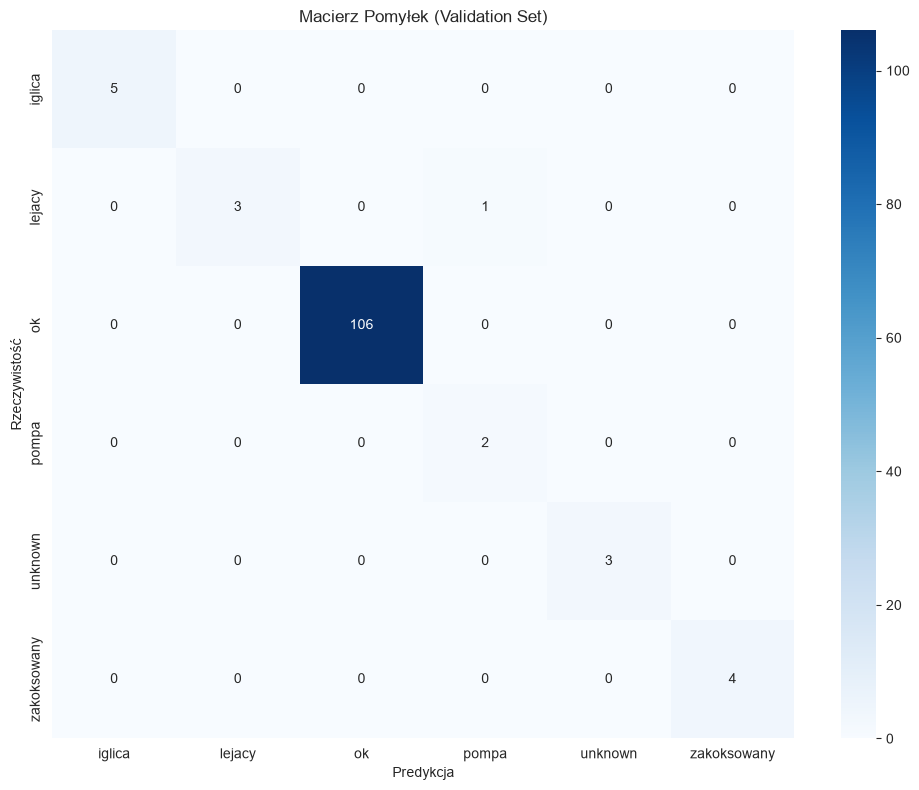

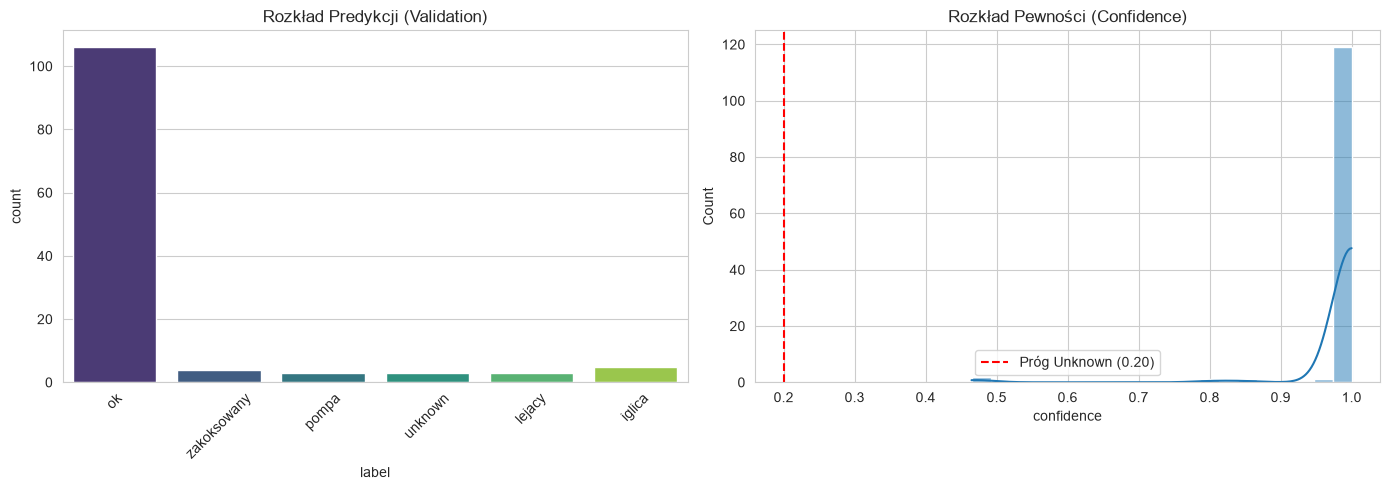

In [56]:
# Macierz pomyłek dla Validation
plt.figure(figsize=(10, 8))
cm = confusion_matrix(val_df['label'], val_results['label'], labels=label_enc.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_enc.classes_, yticklabels=label_enc.classes_)
plt.title('Macierz Pomyłek (Validation Set)')
plt.xlabel('Predykcja')
plt.ylabel('Rzeczywistość')
plt.tight_layout()
plt.show()

# Rozkład predykcji
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='label', data=val_results, ax=ax[0], palette='viridis')
ax[0].set_title('Rozkład Predykcji (Validation)')
ax[0].tick_params(axis='x', rotation=45)

sns.histplot(val_results['confidence'], bins=20, ax=ax[1], kde=True)
ax[1].set_title('Rozkład Pewności (Confidence)')
ax[1].axvline(best_thresh, color='red', linestyle='--', label=f'Próg Unknown ({best_thresh:.2f})')
ax[1].legend()

plt.tight_layout()
plt.show()